In [1]:
import numpy as np
import pandas as pd
from scipy import stats

# 1. Select metric type here ("std" or "ci")
STAT_TYPE = "std"  # Change to "ci" whenever you want Confidence Intervals


def summarize_metric(group, column, stat_type=STAT_TYPE, confidence=0.95):
    """Summarizes a column as Mean ± [Std | CI] (raw_values)."""
    values = group[column].dropna().to_numpy(dtype=float)
    n = len(values)

    if n == 0:
        return "N/A"

    mean = np.mean(values)

    if n > 1:
        if stat_type == "std":
            margin = np.std(values, ddof=1)
        elif stat_type == "ci":
            sem = stats.sem(values)
            margin = sem * stats.t.ppf((1 + confidence) / 2, df=n - 1)
        else:
            raise ValueError("stat_type must be either 'std' or 'ci'")

        margin_str = f"{margin:.2f}"
    else:
        margin_str = "N/A"

    actual = ", ".join(f"{x:.2f}" for x in values)

    return f"{mean:.2f} ± {margin_str} ({actual})"




from pathlib import Path
import json

import numpy as np
import pandas as pd

def actual_sampler(args):
    requested = args.get("sampler", "auto")

    if requested != "auto":
        return requested

    objective = args.get("objective")

    defaults = {
        "ddpm": "ddim",
        "edm": "heun",
        "flow_matching": "euler",
    }

    return defaults.get(objective, "unknown")

def summarize_run(run_dir, tail_n=5):
    run_dir = Path(run_dir)

    with open(run_dir / "args.json", encoding="utf-8") as f:
        args = json.load(f)

    # Detect original JiT runs from the trainer copy created in run_dir.
    if (run_dir / "train_jit_original.py").exists():
        assert "profile_encoder" not in args
        assert "backbone" not in args
        assert "objective" not in args

        args.setdefault("profile_encoder", "mlp")
        args.setdefault("backbone", "dit")
        args.setdefault("objective", "jit_original")

    elif (run_dir / "train_jit.py").exists():
        assert "profile_encoder" not in args
        assert "backbone" not in args

        args.setdefault("profile_encoder", "mlp")
        args.setdefault("backbone", "dit")
        
    fid_path = run_dir / "validation_fid.jsonl"
    fids = []

    if fid_path.exists():
        with open(fid_path, encoding="utf-8") as f:
            fids = [
                json.loads(line)
                for line in f
                if line.strip()
            ]

    row = {
        "run": run_dir.name,
        **{f"arg_{key}": value for key, value in args.items()},
        "actual_sampler": actual_sampler(args),
        "fid_best": np.nan,
        "fid_best_iteration": np.nan,
        "fid_final": np.nan,
        "fid_final_iteration": np.nan,
        "fid_tail_median": np.nan,
        "fid_tail_mean": np.nan,
        "fid_tail_max": np.nan,
        "fid_tail_n": 0,
        "run_full": str(run_dir),
    }

    if fids:
        values = np.array([item["fid"] for item in fids], dtype=float)
        iterations = np.array([item["iteration"] for item in fids])

        tail = values[-tail_n:]

        best_index = np.argmin(values)

        row.update({
            "fid_best": values[best_index],
            "fid_best_iteration": iterations[best_index],
            "fid_final": values[-1],
            "fid_final_iteration": iterations[-1],
            "fid_tail_median": np.median(tail),
            "fid_tail_mean": np.mean(tail),
            "fid_tail_max": np.max(tail),
            "fid_tail_n": len(tail),
        })

    return row



def summarize_runs(experiment_dirs, tail_n=5):
    """Summarizes all run subdirectories found inside multiple experiment directories."""
    rows = []

    # Handle both a single path string/Path object and a list of paths
    if isinstance(experiment_dirs, (str, Path)):
        experiment_dirs = [experiment_dirs]

    for exp_dir in experiment_dirs:
        exp_path = Path(exp_dir)

        # Iterate through subdirectories inside each experiment root
        for run_dir in exp_path.iterdir():
            # Check if it's a directory and contains args.json
            if run_dir.is_dir() and (run_dir / "args.json").exists():
                rows.append(summarize_run(run_dir, tail_n=tail_n))

    return pd.DataFrame(rows)

# Example usage:


In [7]:
# 2. Build comparison DataFrame
suffix = "std" if STAT_TYPE == "std" else "95ci"

dirs = [
    "/home/satoshi/projects/fcmstylegan/experiments/eeeg/diffusion/",
    "/home/satoshi/projects/fcmstylegan/experiments/diffusion/phase1_compact/",
    "/home/satoshi/projects/fcmstylegan/experiments/diffusion/phase2_adm/",

]
df = summarize_runs(dirs)

df = df[df['actual_sampler']!='ddim']


comparison = (
    df.groupby(
        [   
            "arg_batch",
            "arg_seed",
            "arg_profile_encoder",
            "arg_backbone",
            "arg_objective",
            "actual_sampler",
            "fid_final_iteration",
            "run_full"
            
        ],
        dropna=False,
    )
    .apply(
        lambda g: pd.Series({
            "runs": len(g),
            f"tail_fid_{suffix}": summarize_metric(g, "fid_tail_median", stat_type=STAT_TYPE),
            f"best_fid_{suffix}": summarize_metric(g, "fid_best", stat_type=STAT_TYPE),
            f"final_fid_{suffix}": summarize_metric(g, "fid_final", stat_type=STAT_TYPE),
            f"tail_max_fid_{suffix}": summarize_metric(g, "fid_tail_max", stat_type=STAT_TYPE),
        })
    )
)

display(comparison)

runs  \
arg_batch arg_seed arg_profile_encoder arg_backbone arg_objective actual_sampler fid_final_iteration run_full                                                   
128       123      cnn                 adm          edm           heun           275000              /home/satoshi/projects/fcmstylegan/experiments/...     1   
                                       compact      ddpm          ddpm           195000              /home/satoshi/projects/fcmstylegan/experiments/...     1   
                   mlp                 adm          edm           heun           295000              /home/satoshi/projects/fcmstylegan/experiments/...     1   
                                                                                 300000              /home/satoshi/projects/fcmstylegan/experiments/...     1   
                                       compact      ddpm          ddpm           300000              /home/satoshi/projects/fcmstylegan/experiments/...     1   

                                                                                                                                                                tail_fid_std  \
arg_batch arg_seed arg_profile_encoder arg_backbone arg_objective actual_sampler fid_final_iteration run_full                                                                  
128       123      cnn                 adm          edm           heun           275000              /home/satoshi/projects/fcmstylegan/experiments/...  17.53 ± N/A (17.53)   
                                       compact      ddpm          ddpm           195000              /home/satoshi/projects/fcmstylegan/experiments/...  13.51 ± N/A (13.51)   
                   mlp                 adm          edm           heun           295000              /home/satoshi/projects/fcmstylegan/experiments/...  15.09 ± N/A (15.09)   
                                                                                 300000              /home/satoshi/projects/fcmstylegan/experiments/...  14.73 ± N/A (14.73)   
                                       compact      ddpm          ddpm           300000              /home/satoshi/projects/fcmstylegan/experiments/...  12.72 ± N/A (12.72)   

                                                                                                                                                                best_fid_std  \
arg_batch arg_seed arg_profile_encoder arg_backbone arg_objective actual_sampler fid_final_iteration run_full                                                                  
128       123      cnn                 adm          edm           heun           275000              /home/satoshi/projects/fcmstylegan/experiments/...  11.88 ± N/A (11.88)   
                                       compact      ddpm          ddpm           195000              /home/satoshi/projects/fcmstylegan/experiments/...  12.46 ± N/A (12.46)   
                   mlp                 adm          edm           heun           295000              /home/satoshi/projects/fcmstylegan/experiments/...  11.92 ± N/A (11.92)   
                                                                                 300000              /home/satoshi/projects/fcmstylegan/experiments/...  12.10 ± N/A (12.10)   
                                       compact      ddpm          ddpm           300000              /home/satoshi/projects/fcmstylegan/experiments/...  12.41 ± N/A (12.41)   

                                                                                                                                                               final_fid_std  \
arg_batch arg_seed arg_profile_encoder arg_backbone arg_objective actual_sampler fid_final_iteration run_full                                                                  
128       123      cnn                 adm          edm           heun           275000              /home/satoshi/projects/fcmstylegan/experiments/...  16.12 ± N/A (16.12)   
                               

- `backbone`: The `compact` or `adm` U-Net choice affects the network architecture, not the meaning of the objective or sampler.
- `objective` describes how the model is trained.  
- `sampler` describes how images are generated after training.

| Objective | Model learns to predict | Compatible samplers |
|---|---|---|
| `ddpm` | Added Gaussian noise `ε` | `ddpm`, `ddim` |
| `edm` | EDM-preconditioned denoising residual | `euler`, `heun` |
| `flow_matching` | Velocity from noise to image | `euler`, `heun` |

There is no `ddim` objective because DDIM is not a training objective. It is a sampling algorithm for a model trained with the DDPM objective.

For example:

```bash
--objective ddpm --sampler ddim
```

means:

1. Train the model to predict noise using DDPM.
2. Generate images using the DDIM sampling trajectory.

Similarly:

```bash
--objective flow_matching --sampler heun
```

means:

1. Train the model to predict flow velocity.
2. Integrate that velocity using Heun’s method.



# experiment plans
- do not use `ddim` or `euler` as they are just approximation to make inference faster. then we only have 3 x 3 = 9 options
- `backbone` has three choices {`compact`,`adm`,`dit`}. 
- (`objective`,`sampler`) also has three choices {(`ddpm`,`ddpm`),(`edm`,`heun`),(`flow_matching`,`heun`)}
- Default three choices (`backbone`,`objective`,`sampler`) should be 
    - (`compact`,`ddpm`,`ddpm`)
    - (`adm`,`edm`,`heun`)
    - (`dit`,`flow_matching`,`heun`)



In [3]:
from itertools import product
import shlex

python = "python"
gpu = "3"

datasplit = "./data/task1_dataset_split.csv"
preprocessed_root = "/dev/shm/satoshi.tsutsui/data/task1_processed"
sweep_root = "experiments/diffusion_sweep"

seeds = range(4)

backbones = {
    "dit": {
        "script": "train_jit.py",
        "args": ["--model", "JiT-B/16"],
    },
    "compact": {
        "script": "train_diffusion.py",
        "args": ["--backbone", "compact"],
    },
    "adm": {
        "script": "train_diffusion.py",
        "args": ["--backbone", "adm"],
    },
}

objective_sampler_pairs = [
    ("ddpm", "ddpm"),
    ("edm", "heun"),
    ("flow_matching", "heun"),
]

common_args = [
    "--datasplit", datasplit,
    "--preprocessed_root", preprocessed_root,
    "--batch", "128",
    "--bf16",
    "--compile_mode", "default",
    "--fid_samples", "1000",
]

commands = []

for seed, (backbone, (objective, sampler)) in product(
    seeds,
    product(backbones, objective_sampler_pairs),
):
    config_name = f"{backbone}_{objective}_seed{seed}"
    exp_dir = f"{sweep_root}"

    command_parts = [
        python,
        backbones[backbone]["script"],
        *common_args,
        *backbones[backbone]["args"],
        "--objective", objective,
        "--sampler", sampler,
        "--seed", str(seed),
        "--exp_dir", exp_dir,
    ]

    commands.append(" ".join(shlex.quote(part) for part in command_parts))

output_path = "../exp_diffusion_sweep.yaml"
output_path = Path(output_path)
with output_path.open("w", encoding="utf-8") as file:
    for command in commands:
        file.write(f"- cmd: {command}\n")

In [5]:
# 2. Build comparison DataFrame
suffix = "std" if STAT_TYPE == "std" else "95ci"

dirs = [
    "/home/satoshi/projects/fcmstylegan/experiments/eeeg/diffusion_sweep/",
    "/home/satoshi/projects/fcmstylegan/experiments/diffusion/jit/",
    "/home/satoshi/projects/fcmstylegan/experiments/diffusion/jit_original",
    "/home/satoshi/projects/fcmstylegan/experiments/diffusion/jit_original_lrfix",
]
df = summarize_runs(dirs)

df = df[df['actual_sampler']!='ddim']


comparison = (
    df.groupby(
        [   
            "arg_batch",
            # "arg_seed",
            "arg_profile_encoder",
            "arg_backbone",
            "arg_objective",
            "actual_sampler",
            "fid_final_iteration",
            "run_full"
            
        ],
        dropna=False,
    )
    .apply(
        lambda g: pd.Series({
            "runs": len(g),
            f"tail_fid_{suffix}": summarize_metric(g, "fid_tail_median", stat_type=STAT_TYPE),
            f"best_fid_{suffix}": summarize_metric(g, "fid_best", stat_type=STAT_TYPE),
            f"final_fid_{suffix}": summarize_metric(g, "fid_final", stat_type=STAT_TYPE),
            f"tail_max_fid_{suffix}": summarize_metric(g, "fid_tail_max", stat_type=STAT_TYPE),
        })
    )
)

display(comparison)

runs  \
arg_batch arg_profile_encoder arg_backbone arg_objective actual_sampler fid_final_iteration run_full                                                   
128       mlp                 adm          ddpm          ddpm           160000              /home/satoshi/projects/fcmstylegan/experiments/...     1   
                                           edm           heun           235000              /home/satoshi/projects/fcmstylegan/experiments/...     1   
                                           flow_matching heun           220000              /home/satoshi/projects/fcmstylegan/experiments/...     1   
                              compact      ddpm          ddpm           50000               /home/satoshi/projects/fcmstylegan/experiments/...     1   
                                                                        300000              /home/satoshi/projects/fcmstylegan/experiments/...     1   
                                           edm           heun           300000              /home/satoshi/projects/fcmstylegan/experiments/...     1   
                                           flow_matching heun           300000              /home/satoshi/projects/fcmstylegan/experiments/...     1   
                              dit          ddpm          ddpm           300000              /home/satoshi/projects/fcmstylegan/experiments/...     1   
                                           edm           heun           300000              /home/satoshi/projects/fcmstylegan/experiments/...     1   
                                           flow_matching heun           300000              /home/satoshi/projects/fcmstylegan/experiments/...     1   
                                                                                            /home/satoshi/projects/fcmstylegan/experiments/...     1   
                                           jit_original  heun           265000              /home/satoshi/projects/fcmstylegan/experiments/...     1   
                                                                        300000              /home/satoshi/projects/fcmstylegan/experiments/...     1   
1024      mlp                 dit          flow_matching heun           85000               /home/satoshi/projects/fcmstylegan/experiments/...     1   
                                           jit_original  heun           50000               /home/satoshi/projects/fcmstylegan/experiments/...     1   

                                                                                                                                                         tail_fid_std  \
arg_batch arg_profile_encoder arg_backbone arg_objective actual_sampler fid_final_iteration run_full                                                                    
128       mlp                 adm          ddpm          ddpm           160000              /home/satoshi/projects/fcmstylegan/experiments/...    13.81 ± N/A (13.81)   
                                           edm           heun           235000              /home/satoshi/projects/fcmstylegan/experiments/...    14.86 ± N/A (14.86)   
                                           flow_matching heun           220000              /home/satoshi/projects/fcmstylegan/experiments/...    19.05 ± N/A (19.05)   
                              compact      ddpm          ddpm           50000               /home/satoshi/projects/fcmstylegan/experiments/...    38.70 ± N/A (38.70)   
                                                                        300000              /home/satoshi/projects/fcmstylegan/experiments/...    13.39 ± N/A (13.39)   
                                           edm           heun           300000              /home/satoshi/projects/fcmstylegan/experiments/...    15.38 ± N/A (15.38)   
                                           flow_matching heun           300000              /home/satoshi/projects/fcmstylegan/experiments/...    16.75 ± N/A (16.75)   
                              dit     

# visualize the basic (compact + DDPM)
- /home/satoshi/projects/fcmstylegan/experiments/diffusion/phase1_compact/20260824_190314




,iteration,fid
1,10000,182.219599
3,20000,178.296571
5,30000,120.105805
7,40000,53.521208
9,50000,26.578321
11,60000,19.999232
13,70000,16.228428
15,80000,15.575062
17,90000,15.894983
19,100000,14.254550


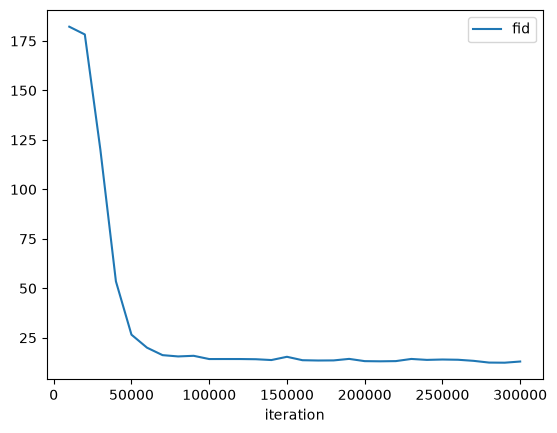

In [9]:
fid_path = "../experiments/diffusion/phase1_compact/20260824_190314/validation_fid.jsonl"
with open(fid_path, encoding="utf-8") as f:
    fids = [
        json.loads(line)
        for line in f
        if line.strip()
    ]
df_fid_all = pd.DataFrame(fids)
df_fid = df_fid_all.query("iteration%10000==0")#because checkpoing is every 10000 
df_fid.plot(x="iteration",y="fid")
display(df_fid)



python evaluate.py \
    --model diffusion \
    --ckpt experiments/diffusion/phase1_compact/20260824_190314/checkpoint/290000.pt \
    --datasplit data/task1_dataset_split.csv \
    --preprocessed_root data/task1_processed \
    --split test \
    --use_mask \
    --seed 123 \
    --save_images_dir experiments/diffusion/phase1_compact/20260824_190314/test_eval_imgs \
    --output experiments/diffusion/phase1_compact/20260824_190314/test_eval_stat.json \
    --per_image_output experiments/diffusion/phase1_compact/20260824_190314/test_eval_imgs.jsonl


(fcmstylegan) satoshi@olliemain:~/projects/fcmstylegan$ rsync -aAX --info=progress2 --no-i-r  rosea100:/home/satoshi/projects/fcmstylegan/experiments/diffusion/phase1_compact/20260824_190314/  experiments/diffusion/phase1_compact/20260824_190314/

satoshi@a100:~/projects/fcmstylegan$ rsync -aAX --info=progress2 --no-i-r /home/satoshi/projects/fcmstylegan/experiments/diffusion/phase1_compact/20260824_190314/  eeeg:/home/satoshi.tsutsui/fcmstylegan/experiments/diffusion/phase1_compact/20260824_190314/

,value
model,diffusion
checkpoint,/projects/_hdd/satoshihdd/experiments/fcmstyle...
split,test
num_samples,34753
seed,123
mask_metrics,True
fid,3.199055
psnr_mean,20.509
ssim_mean,0.893614
psnr_masked_mean,13.169148


,mean,median,std,min,max,count
psnr,20.5090,21.1137,4.2415,4.8393,32.3204,34753.0000
ssim,0.8936,0.9019,0.0416,0.4213,0.9863,34753.0000
psnr_masked,13.1691,13.3831,1.5711,4.7462,21.4277,34753.0000
ssim_masked,0.1171,0.0980,0.1402,-0.4694,0.7562,34753.0000
lpips,0.1315,0.1214,0.0503,0.0341,0.6124,34753.0000
lpips_crop,0.2288,0.2215,0.0635,0.0684,0.7836,34753.0000


,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part3_T Lymph_21735,32.32,0.9863,18.97,0.7562,0.0341,0.0684


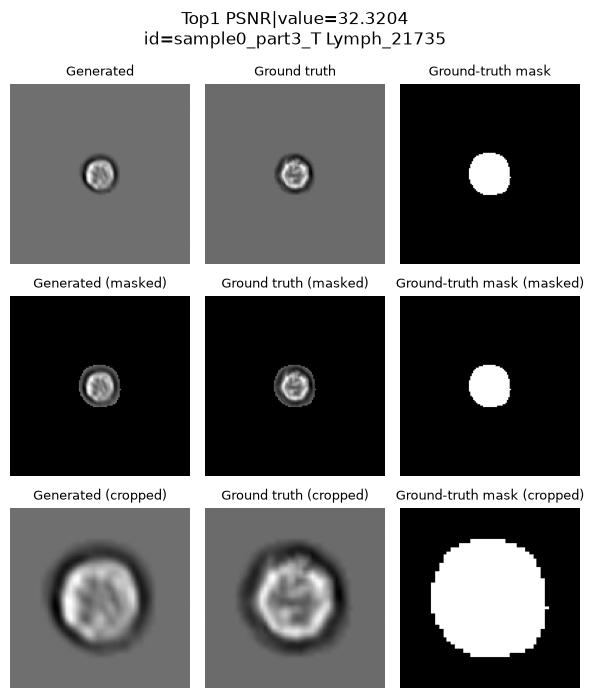

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part3_Neut_8679,21.11,0.8939,13.10,0.0606,0.1783,0.3462


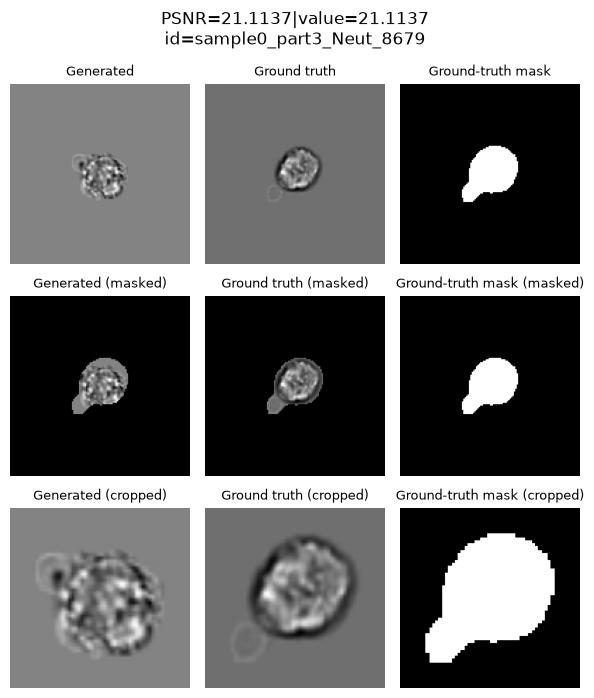

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part3_T Lymph_27289,4.84,0.4928,4.75,0.1007,0.4558,0.5324


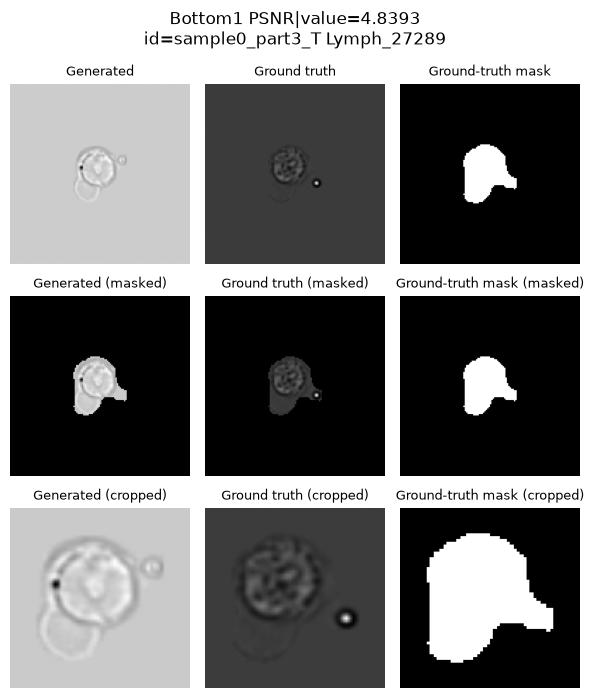

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part3_T Lymph_21735,32.32,0.9863,18.97,0.7562,0.0341,0.0684


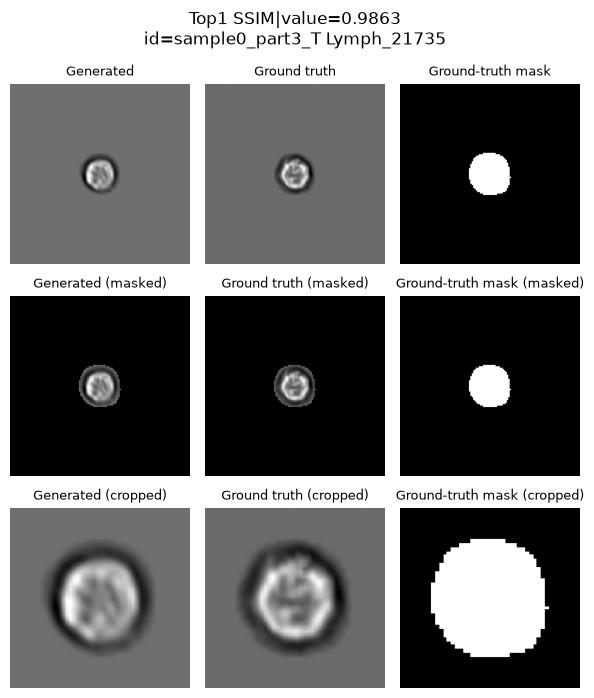

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part3_T Lymph_13601,14.90,0.9019,12.07,0.3403,0.1405,0.1721


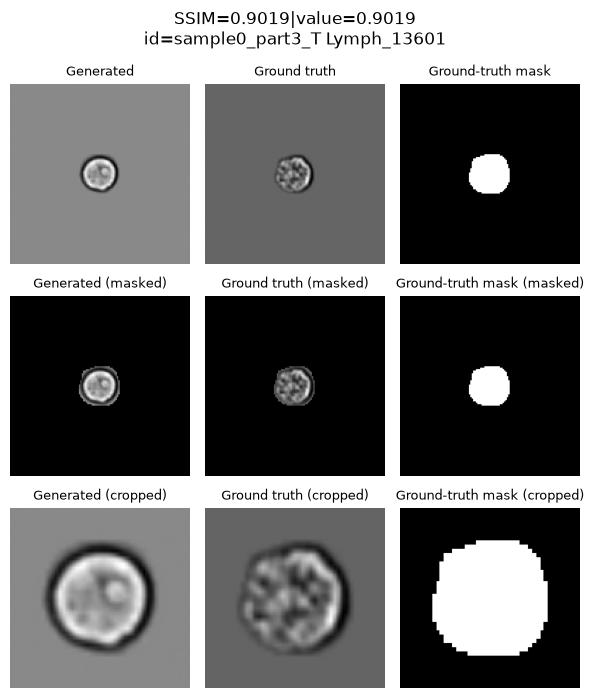

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part1_Neut_2337,14.03,0.4213,13.89,0.1406,0.4861,0.5606


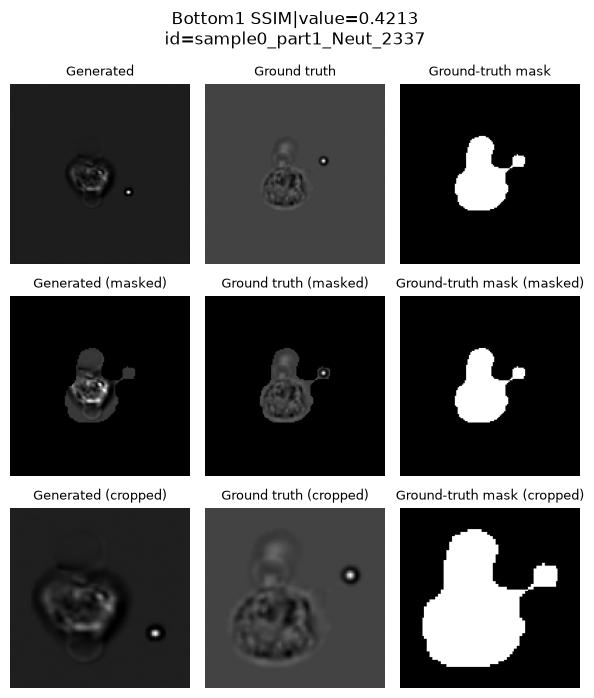

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part2_T Lymph_22688,30.88,0.9725,21.43,0.5770,0.0414,0.0862


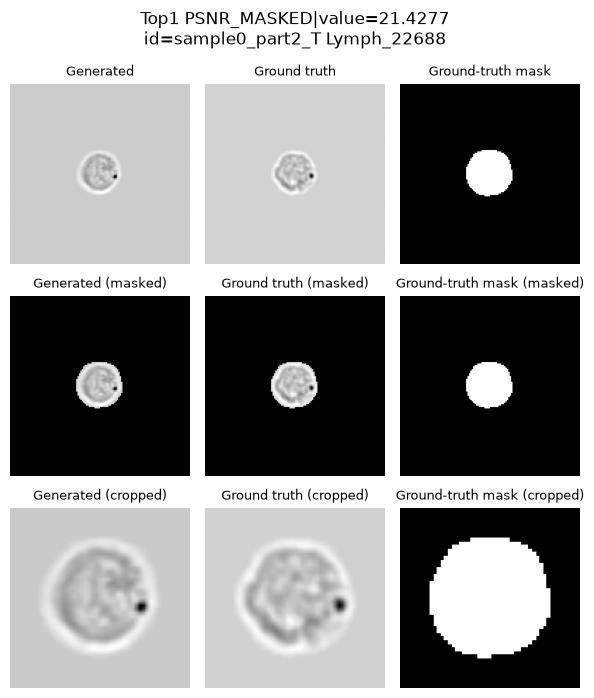

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part2_B Lymph_6422,23.38,0.9302,13.38,0.1074,0.1332,0.2185


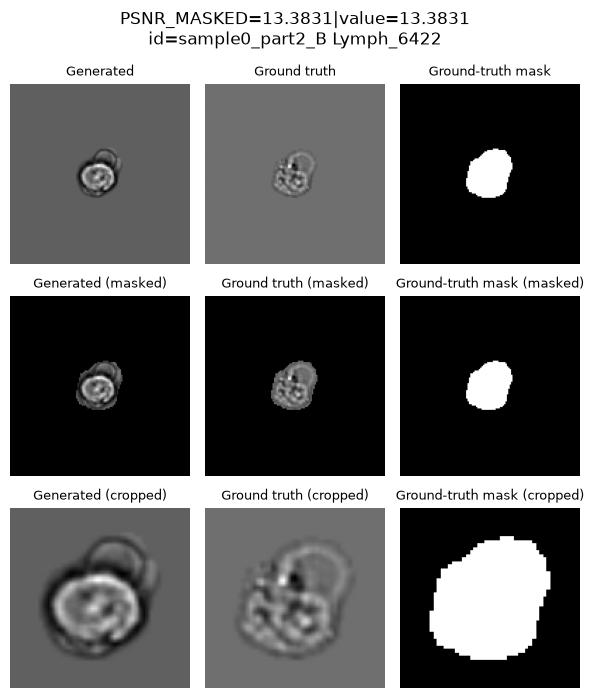

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part3_T Lymph_27289,4.84,0.4928,4.75,0.1007,0.4558,0.5324


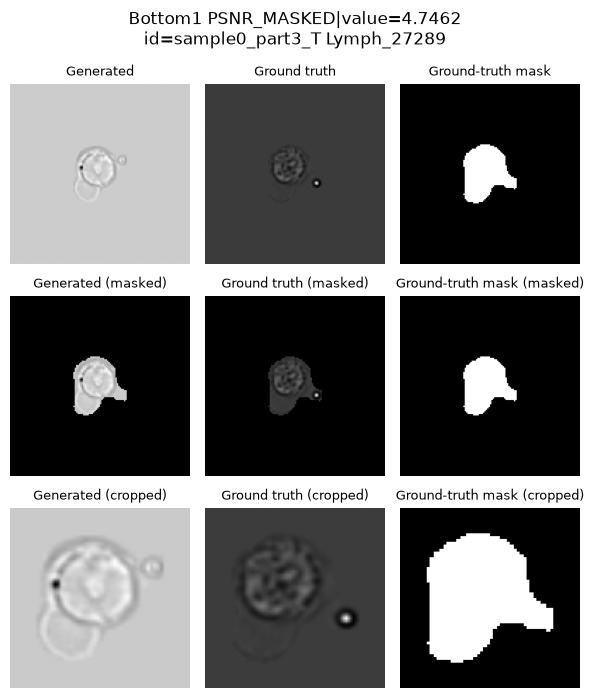

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part3_T Lymph_21735,32.32,0.9863,18.97,0.7562,0.0341,0.0684


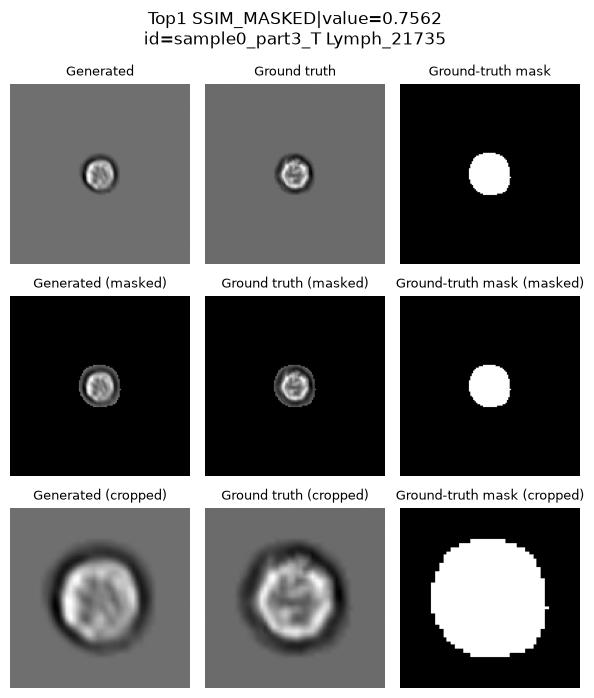

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part2_Neut_29451,23.19,0.9034,13.91,0.0980,0.0825,0.1677


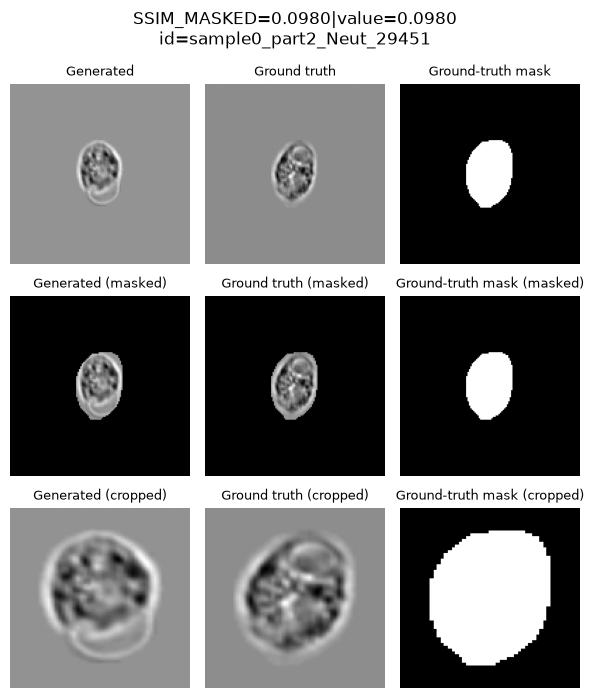

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part3_Neut_35426,10.25,0.7579,7.25,-0.4694,0.2727,0.2625


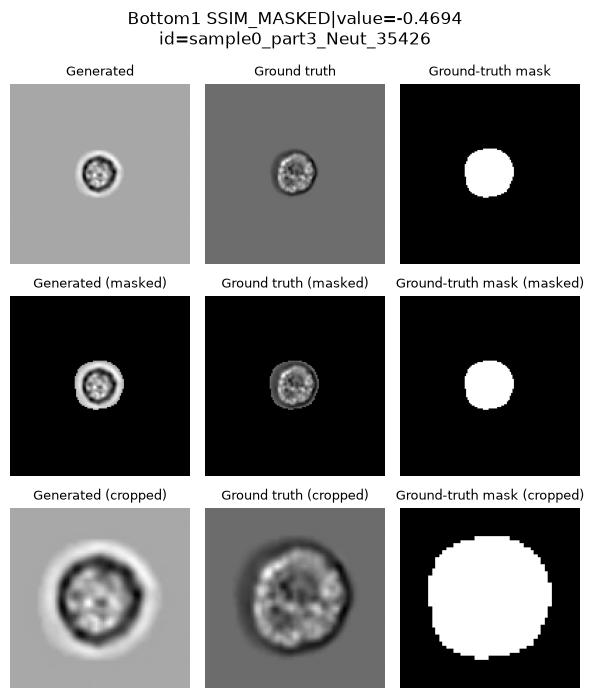

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part2_Neut_7876,27.88,0.9681,18.27,0.6371,0.0341,0.0861


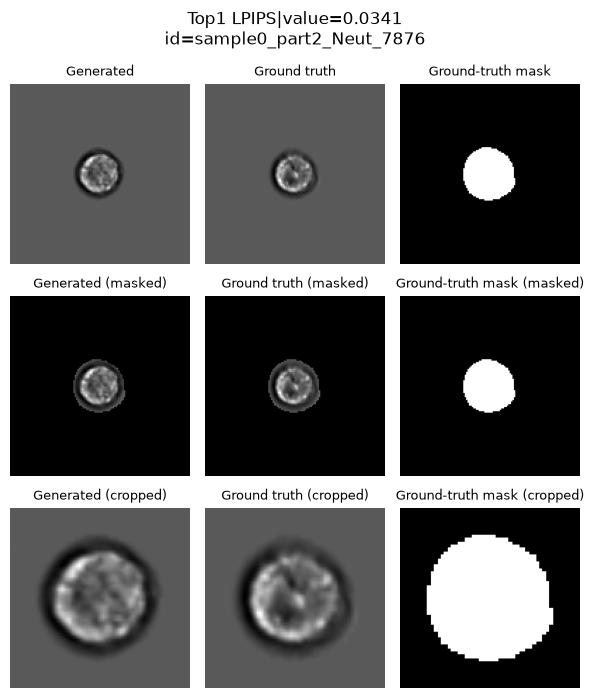

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part1_Neut_22898,21.89,0.9073,13.36,-0.0213,0.1214,0.2267


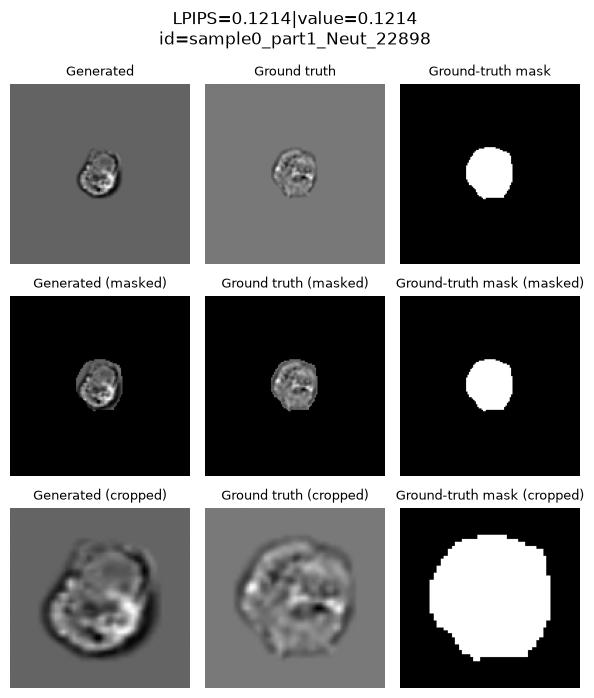

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part2_B Lymph_14906,7.47,0.8167,6.06,0.0408,0.6124,0.7836


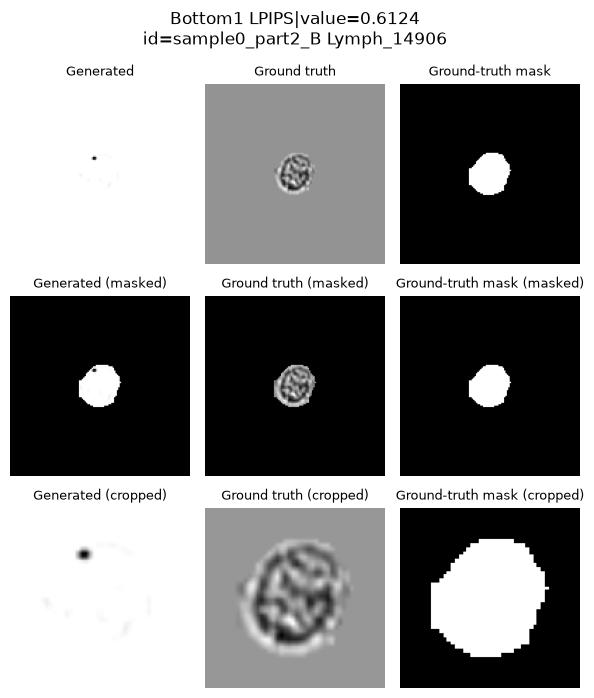

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part3_T Lymph_21735,32.32,0.9863,18.97,0.7562,0.0341,0.0684


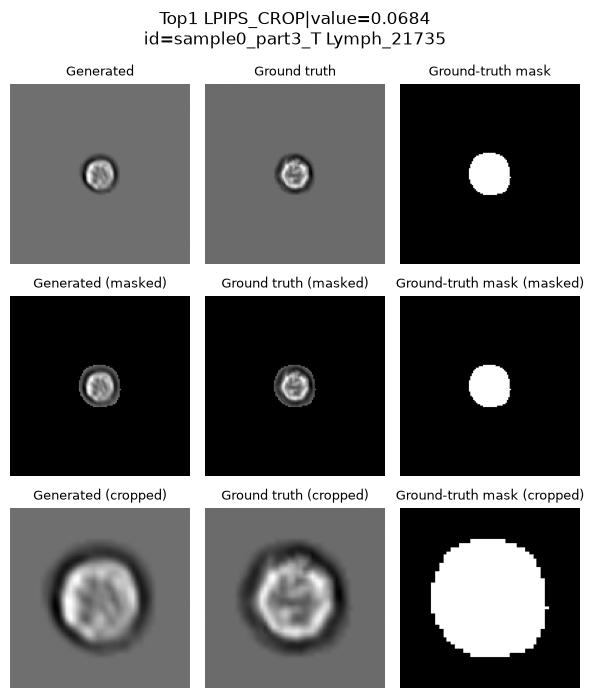

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part1_Neut_10615,19.05,0.9040,14.51,0.2558,0.1396,0.2215


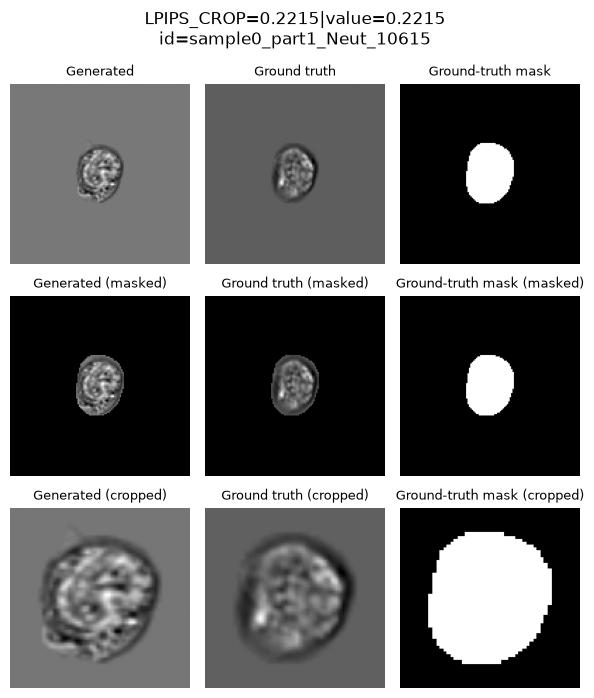

,psnr,ssim,psnr_masked,ssim_masked,lpips,lpips_crop
sample0_part2_B Lymph_14906,7.47,0.8167,6.06,0.0408,0.6124,0.7836


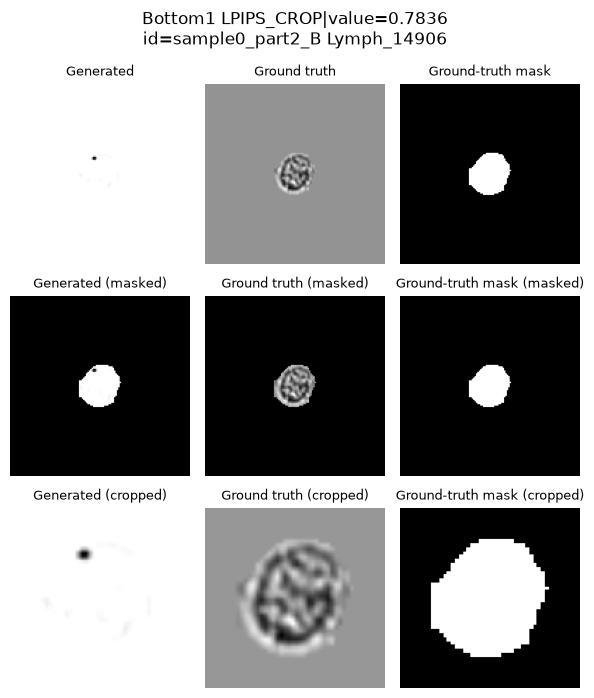

In [1]:
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("jpg")

from pathlib import Path
ROOT = Path("~/projects/fcmstylegan/experiments/archive/ddpm_baseline_20260824_190314").expanduser()
%run -i plot_test_results.py

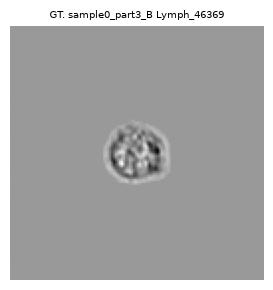

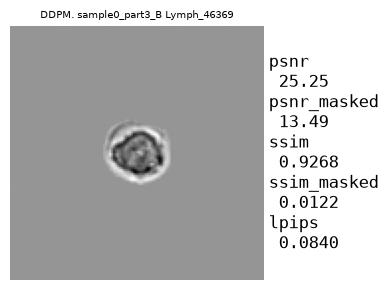

--------------------------------------------------


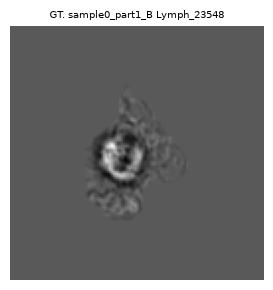

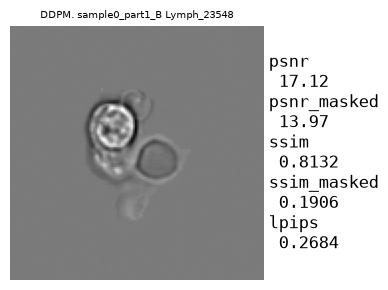

--------------------------------------------------


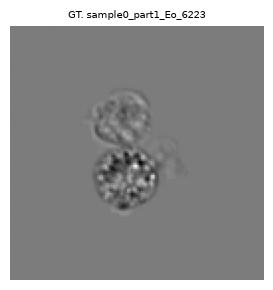

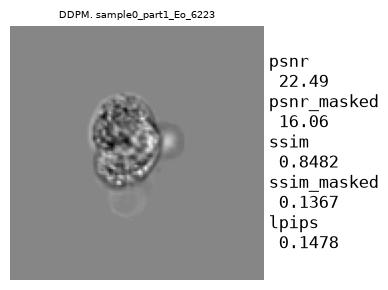

--------------------------------------------------


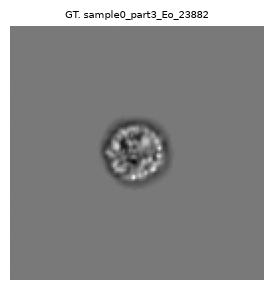

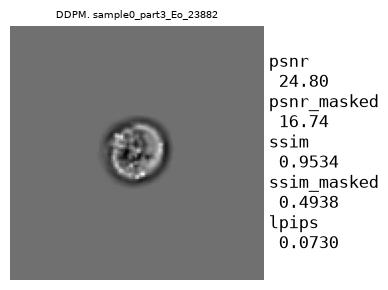

--------------------------------------------------


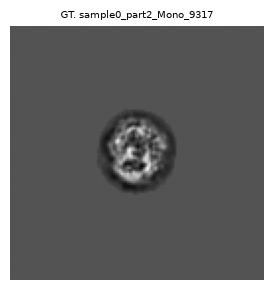

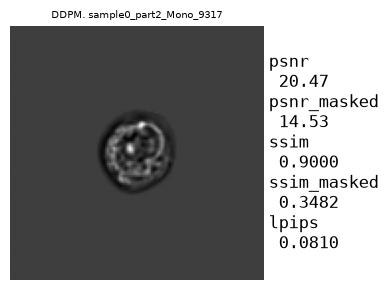

--------------------------------------------------


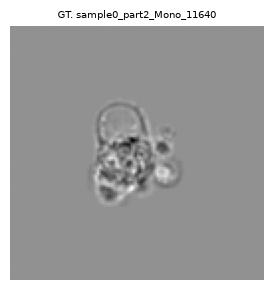

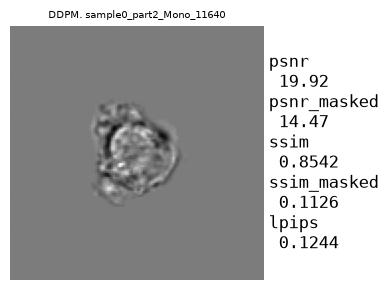

--------------------------------------------------


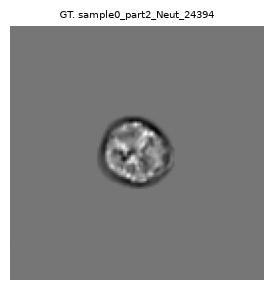

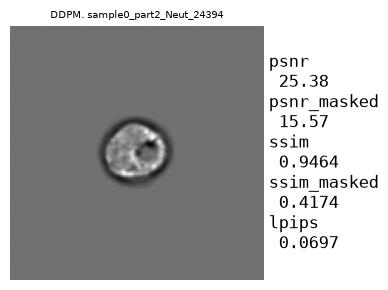

--------------------------------------------------


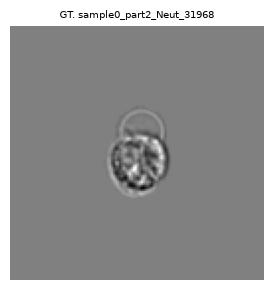

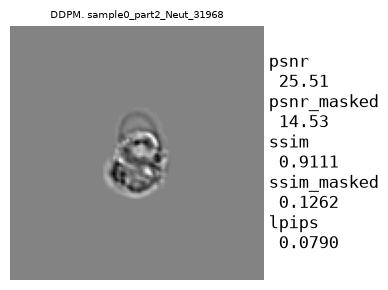

--------------------------------------------------


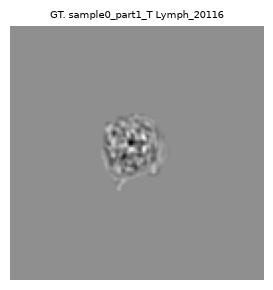

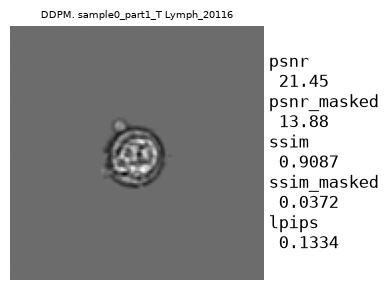

--------------------------------------------------


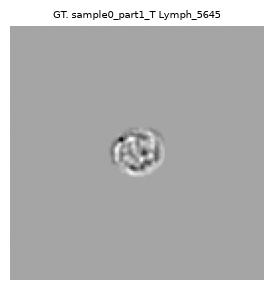

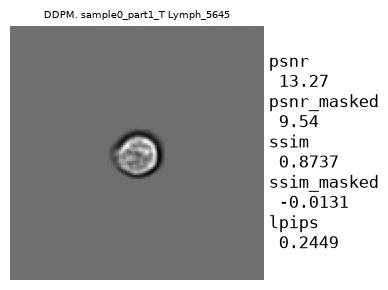

--------------------------------------------------


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib_inline
import matplotlib

matplotlib_inline.backend_inline.set_matplotlib_formats("jpg")
matplotlib.rc("pdf", fonttype=42)

from PIL import Image


# ============================================================
# Placeholder dependencies that need to be defined
# ============================================================
# PREPROCESSED_ROOT = Path("...")
# GENERATED_DIR = Path("...")
# IMAGE_SUFFIX = ".png"
# available_metrics = [...]
# metric_decimals = {}
# df = pd.DataFrame(...)
#
# def safe_id(cell_id): ...
# def crop_to_mask(image, mask_path, resampling): ...


# ============================================================
# Image display helper
# ============================================================

def show_image(
    ax,
    path,
    title,
    mask_path=None,
    cropped=False,
    mask=False,
    masked=False,
):
    ax.axis("off")

    if path.exists():
        # Preserve 16-bit/float image data.
        # Converting to L can wash out GT images.
        image = Image.open(path)

        if cropped:
            image = crop_to_mask(
                image,
                mask_path,
                resampling=(
                    Image.Resampling.NEAREST
                    if mask
                    else Image.Resampling.BILINEAR
                ),
            )

        image_array = np.asarray(image)

        if masked:
            mask_image = (
                Image.open(mask_path)
                .convert("L")
                .resize(image.size, Image.Resampling.NEAREST)
            )

            mask_array = np.asarray(mask_image) > 0

            image_array = np.where(
                mask_array,
                image_array,
                image_array.min(),
            )

        ax.imshow(image_array, cmap="gray")
        ax.set_title(title, fontsize=7)

    else:
        ax.text(
            0.5,
            0.5,
            f"Missing:\n{path}",
            ha="center",
            va="center",
            fontsize=8,
        )


# ============================================================
# Metrics helper
# ============================================================

def _get_metrics_text(sample, metrics):
    """Format specified metrics into a single string."""
    lines = []

    for metric in metrics:
        val = sample[metric]
        decimals = metric_decimals.get(metric, 4)

        formatted_val = (
            f"{val:.{decimals}f}"
            if pd.notna(val)
            else "N/A"
        )

        lines.append(f"{metric}\n {formatted_val}")

    return "\n".join(lines)


# ============================================================
# Ground Truth plot
# ============================================================

def plot_gt(cell_id, figsize=(4, 4)):
    """Create a Ground Truth figure and return (fig, ax)."""

    matches = df[
        df["image_id"].astype(str) == str(cell_id)
    ]

    if matches.empty:
        raise KeyError(f"Cell ID not found: {cell_id}")

    gt_path = (
        PREPROCESSED_ROOT
        / f"{str(cell_id)}{IMAGE_SUFFIX}"
    )

    fig, ax = plt.subplots(figsize=figsize)

    show_image(
        ax,
        gt_path,
        f"GT. {cell_id}",
    )

    plt.tight_layout()

    return fig, ax


# ============================================================
# Generated plot
# ============================================================

def plot_gen(
    cell_id,
    metrics=None,
    figsize=(4, 4),
    fontsize=10,
    model_name="Gen",
):
    """Create a Generated figure and return (fig, ax)."""

    matches = df[
        df["image_id"].astype(str) == str(cell_id)
    ]

    if matches.empty:
        raise KeyError(f"Cell ID not found: {cell_id}")

    sample = matches.iloc[0]

    # Use all available metrics by default
    if metrics is None:
        metrics = available_metrics

    else:
        invalid = [
            m for m in metrics
            if m not in available_metrics
        ]

        if invalid:
            raise ValueError(
                f"Unknown metric(s): {invalid}; "
                f"choose from {available_metrics}"
            )

    generated_path = (
        GENERATED_DIR
        / f"{safe_id(cell_id)}.png"
    )

    fig, ax = plt.subplots(figsize=figsize)

    show_image(
        ax,
        generated_path,
        f"{model_name}. {cell_id}",
    )

    metrics_str = _get_metrics_text(
        sample,
        metrics,
    )

    fig.text(
        1.02,
        0.5,
        metrics_str,
        transform=ax.transAxes,
        fontsize=fontsize,
        verticalalignment="center",
        family="monospace",
    )

    plt.tight_layout()

    return fig, ax


# ============================================================
# Cell IDs
# ============================================================

cell_ids = [
    "sample0_part3_B Lymph_46369",
    "sample0_part1_B Lymph_23548",
    "sample0_part1_Eo_6223",
    "sample0_part3_Eo_23882",
    "sample0_part2_Mono_9317",
    "sample0_part2_Mono_11640",
    "sample0_part2_Neut_24394",
    "sample0_part2_Neut_31968",
    "sample0_part1_T Lymph_20116",
    "sample0_part1_T Lymph_5645",
]


# ============================================================
# Plot configuration
# ============================================================

metrics = [
    "psnr",
    "psnr_masked",
    "ssim",
    "ssim_masked",
    "lpips",
    "lpips_crop",
][:-1]

figsize = (3, 3)
fontsize = 10
model_name = "DDPM"


# ============================================================
# Save + show
# ============================================================

for cell_id in cell_ids:

    # --------------------------------------------------------
    # Ground Truth
    # --------------------------------------------------------

    fig, ax = plot_gt(
        cell_id,
        figsize=figsize,
    )

    fig.savefig(
        f"../samplevis/{cell_id}-GT.pdf",
        bbox_inches="tight",
        pad_inches=0,
    )

    plt.show()
    plt.close(fig)


    # --------------------------------------------------------
    # Generated
    # --------------------------------------------------------

    fig, ax = plot_gen(
        cell_id,
        figsize=figsize,
        fontsize=12,
        metrics=metrics,
        model_name=model_name,
    )

    fig.savefig(
        f"../samplevis/{cell_id}-{model_name}.pdf",
        bbox_inches="tight",
        pad_inches=0,
    )

    plt.show()
    plt.close(fig)


    print("-" * 50)


In [3]:
from pathlib import Path
from pypdf import PageObject, PdfReader, PdfWriter

# Configuration
VIS_DIR = Path("../samplevis")
OUTPUT_PDF = VIS_DIR / "combined_comparison.pdf"

# Add or remove models here to dynamically adjust columns
MODELS = ["DCGAN", "StyleGAN", "DDPM"]

# Whether GT should be placed as the last column.
# False: GT | DCGAN | StyleGAN
# True:  DCGAN | StyleGAN | GT
GT_LAST = True

cell_ids = [
    "sample0_part3_B Lymph_46369",
    "sample0_part1_B Lymph_23548",
    "sample0_part1_Eo_6223",
    "sample0_part3_Eo_23882",
    "sample0_part2_Mono_9317",
    "sample0_part2_Mono_11640",
    "sample0_part2_Neut_24394",
    "sample0_part2_Neut_31968",
    "sample0_part1_T Lymph_20116",
    "sample0_part1_T Lymph_5645",
]


def load_row_page(cell_id, models, input_dir, gt_last=False):
    """Combine GT + Model PDFs horizontally for a single cell_id."""

    gt_path = input_dir / f"{cell_id}-GT.pdf"
    model_paths = [
        input_dir / f"{cell_id}-{model}.pdf"
        for model in models
    ]

    # Choose column order
    if gt_last:
        pdf_paths = model_paths + [gt_path]
    else:
        pdf_paths = [gt_path] + model_paths

    pages = []
    for path in pdf_paths:
        if not path.exists():
            raise FileNotFoundError(f"Missing required PDF: {path}")

        reader = PdfReader(path)
        pages.append(reader.pages[0])

    row_width = sum(float(p.mediabox.width) for p in pages)
    row_height = max(float(p.mediabox.height) for p in pages)

    row_page = PageObject.create_blank_page(
        width=row_width,
        height=row_height
    )

    current_x = 0.0
    for p in pages:
        row_page.merge_translated_page(
            p,
            tx=current_x,
            ty=0.0
        )
        current_x += float(p.mediabox.width)

    return row_page


def create_comparison_pdf(
    cell_ids,
    models,
    input_dir,
    output_file,
    mode="multi_page",
    gt_last=False,
):
    """
    Concatenate model PDFs horizontally and cell instances vertically.

    Modes:
      - 'multi_page': 1 PDF page per cell_id.
      - 'single_page': All cell_ids stacked vertically onto 1 single long page.

    gt_last:
      - False: GT | Model 1 | Model 2 | ...
      - True:  Model 1 | Model 2 | ... | GT
    """

    writer = PdfWriter()

    row_pages = [
        load_row_page(
            cid,
            models,
            input_dir,
            gt_last=gt_last,
        )
        for cid in cell_ids
    ]

    if mode == "multi_page":
        for page in row_pages:
            writer.add_page(page)

    elif mode == "single_page":
        total_width = max(
            float(p.mediabox.width)
            for p in row_pages
        )
        total_height = sum(
            float(p.mediabox.height)
            for p in row_pages
        )

        single_long_page = PageObject.create_blank_page(
            width=total_width,
            height=total_height
        )

        # PyPDF origins (0,0) start at the bottom-left.
        # Stack rows from the top downward.
        current_y = total_height

        for page in row_pages:
            h = float(page.mediabox.height)
            current_y -= h

            single_long_page.merge_translated_page(
                page,
                tx=0.0,
                ty=current_y
            )

        writer.add_page(single_long_page)

    else:
        raise ValueError(
            f"Invalid mode: '{mode}'. "
            "Use 'multi_page' or 'single_page'."
        )

    with open(output_file, "wb") as f_out:
        writer.write(f_out)

    order = (
        " | ".join(models) + " | GT"
        if gt_last
        else "GT | " + " | ".join(models)
    )

    print(
        f"Successfully generated ({mode}) comparison PDF: "
        f"{output_file}"
    )
    print(f"Column order: {order}")


if __name__ == "__main__":
    create_comparison_pdf(
        cell_ids,
        MODELS,
        VIS_DIR,
        OUTPUT_PDF,
        mode="single_page",
        gt_last=GT_LAST,
    )


Successfully generated (single_page) comparison PDF: ../samplevis/combined_comparison.pdf
Column order: DCGAN | StyleGAN | DDPM | GT
